<table>
 <tr align=left><td><img align=left src="https://i.creativecommons.org/l/by/4.0/88x31.png">
 <td>Text provided under a Creative Commons Attribution license, CC-BY. All code is made available under the FSF-approved MIT license. (c) Kyle T. Mandli</td>
</table>

In [1]:
%matplotlib inline
from __future__ import print_function
import numpy
import matplotlib.pyplot as plt

# **Persamaan Eliptik** (***Elliptic Equations***)



Persamaan eliptik merupakan salah satu jenis persamaan diferensial parsial (Partial Differential Equation / PDE) yang digunakan untuk menggambarkan fenomena keadaan stabil (*steady-state*), yaitu kondisi ketika suatu sistem tidak mengalami perubahan terhadap waktu.

Persamaan ini sering muncul pada berbagai permasalahan yang berkaitan dengan **medan potensial**, seperti distribusi suhu, potensial listrik, maupun medan gravitasi, terutama ketika sistem telah mencapai keadaan keseimbangan.


## Persamaan Eliptik pada Dimensi Lebih Tinggi

Secara umum, bentuk persamaan eliptik dua dimensi dapat dituliskan sebagai

$$
a_1 u_{xx} + a_2 u_{xy} + a_3 u_{yy} + a_4 u_x + a_5 u_y + a_6 u = f
$$

dengan syarat bahwa koefisien-koefisiennya memenuhi

$$
a_2^2 - 4a_1 a_3 < 0
$$

Kondisi tersebut menunjukkan bahwa persamaan tersebut termasuk dalam **kategori persamaan eliptik**.

Salah satu contoh kemunculan persamaan ini adalah pada permasalahan keadaan tunak (*steady-state*) yang berasal dari persamaan panas (*heat equation*).


Dalam dua dimensi, persamaan panas dapat dituliskan sebagai

$$
u_t = (\kappa u_x)_x + (\kappa u_y)_y + \Psi(x,y)
$$

di mana:

- $u$ menyatakan suhu  
- $t$ adalah waktu  
- $\kappa$ adalah konduktivitas panas  
- $\Psi(x,y)$ merupakan sumber panas

Jika sistem telah mencapai **keadaan tunak**, maka suhu tidak berubah terhadap waktu sehingga

$$
u_t = 0
$$

Persamaan tersebut kemudian menjadi

$$
(\kappa u_x)_x + (\kappa u_y)_y = -\Psi(x,y)
$$

Jika diasumsikan bahwa **konduktivitas panas** \(\kappa\) bernilai **konstan**, maka persamaan tersebut dapat disederhanakan menjadi

$$
u_{xx} + u_{yy} = -\frac{\Psi}{\kappa} = f(x,y)
$$

Persamaan ini dikenal sebagai **persamaan Poisson dua dimensi**.

Apabila

$$
f(x,y) = 0
$$

maka persamaan tersebut menjadi **persamaan Laplace**

$$
u_{xx} + u_{yy} = 0
$$

##### Domain dan Kondisi Batas
Dalam menyelesaikan persamaan eliptik, perlu ditentukan **daerah penyelesaian (domain)** yang biasanya dilambangkan dengan $\Omega$, serta **kondisi batas (*boundary conditions*)**.

Karena persamaan ini melibatkan dua variabel yaitu \(x\) dan \(y\), maka kondisi batasnya juga bergantung pada kedua variabel tersebut sehingga penanganannya lebih kompleks dibandingkan dengan kasus satu dimensi.


## 5-Point Stencil

Dengan memperluas pendekatan beda hingga dari satu dimensi ke dua dimensi, diperoleh pendekatan **5-point stencil** untuk operator Laplace sebagai berikut

$$
\nabla^2 u \approx 
\frac{U_{i-1,j} - 2 U_{i,j} + U_{i+1,j}}{\Delta x^2} +
\frac{U_{i,j-1} - 2 U_{i,j} + U_{i,j+1}}{\Delta y^2}
$$

Jika ukuran grid pada arah \(x\) dan \(y\) sama, yaitu

$$
\Delta x = \Delta y
$$

maka persamaan tersebut dapat disederhanakan menjadi

$$
\nabla^2 u \approx 
\frac{U_{i-1,j} + U_{i+1,j} - 4U_{i,j} + U_{i,j-1} + U_{i,j+1}}{\Delta x^2}
$$

Dengan pendekatan ini, solusi dari **persamaan Poisson** dapat diperkirakan melalui hubungan

$$
\frac{U_{i-1,j} + U_{i+1,j} - 4U_{i,j} + U_{i,j-1} + U_{i,j+1}}{\Delta x^2} = f_{i,j}
$$

Pendekatan ini menghasilkan **\(m^2\) persamaan dengan \(m^2\) variabel yang belum diketahui**, yang kemudian dapat diselesaikan untuk memperoleh nilai pendekatan solusi pada setiap titik grid.

---

## Pengurutan Variabel yang Tidak Diketahui (*Ordering of Unknowns*)

Permasalahan dua dimensi biasanya direpresentasikan dalam bentuk 
![2D Grid](./images/2d_grid.png)

Pada grid tersebut:

- titik di **dalam domain** merupakan **variabel yang tidak diketahui**
- titik pada **batas domain** memiliki nilai yang sudah ditentukan oleh kondisi batas

Nilai solusi pada setiap titik interior kemudian dihitung berdasarkan nilai titik-titik di sekitarnya menggunakan pendekatan **5-point stencil**.

Kita dapat memandang grid tersebut sebagai sebuah **matriks** yang dituliskan sebagai

$$
U =
\begin{bmatrix}
U_{1,m} & U_{2,m} & \cdots & U_{m-1,m} & U_{m,m} \\
U_{1,m-1} & U_{2,m-1} & \cdots & U_{m-1,m-1} & U_{m,m-1} \\
\vdots & & & & \vdots \\
U_{1,2} & U_{2,2} & \cdots & U_{m-1,2} & U_{m,2} \\
U_{1,1} & U_{2,1} & \cdots & U_{m-1,1} & U_{m,1}
\end{bmatrix}
$$

Perlu diperhatikan bahwa penomoran indeks pada matriks ini tidak sama dengan notasi matriks yang biasa digunakan

Pada kasus satu dimensi, urutan variabel yang tidak diketahui (dan persamaannya) cukup jelas. Namun pada dua dimensi, kita memiliki beberapa pilihan cara untuk mengurutkannya.

Salah satu cara yang paling sederhana adalah dengan **mengambil setiap baris dari array 2D dan menggabungkannya menjadi satu vektor**. Dengan cara ini kita memperoleh urutan

$$
U =
[U_{1,1}, U_{2,1}, \ldots, U_{m-1,1}, U_{m,1}, U_{1,2}, U_{2,2}, \ldots, U_{m-1,m}, U_{m,m}]
$$

Cobalah untuk menentukan bentuk **matriks $A$** jika kita menggunakan urutan seperti ini.

Dengan pengurutan tersebut, kita akan mendapatkan matriks dengan bentuk

$$
A = \frac{1}{\Delta x^2}
\begin{bmatrix}
T & I \\
I & T & I \\
  & I & T & I \\
  &   & \ddots & \ddots & \ddots \\
  &   &        & I & T & I \\
  &   &        &   & I & T
\end{bmatrix}
$$

di mana matriks $T$ adalah

$$
T =
\begin{bmatrix}
-4 & 1 \\
1 & -4 & 1 \\
  & 1 & -4 & 1 \\
  &   & \ddots & \ddots & \ddots \\
  &   &        & 1 & -4 & 1 \\
  &   &        &   & 1 & -4
\end{bmatrix}
$$

dan $I$ adalah **matriks identitas berukuran $m \times m$**.

### ***Red-Black Ordering***
Cara lain untuk mengurutkan variabel adalah menggunakan metode ***red-black ordering***, yang mirip dengan pola **papan catur**.

Pada metode ini, setiap titik pada grid diberi warna secara bergantian (merah dan hitam). Kemudian semua titik merah dikelompokkan bersama dan semua titik hitam juga dikelompokkan bersama.

![2D Grid Red-Black Ordering](./images/2d_grid_red_black.png)

Cobalah untuk menentukan bentuk matriks yang dihasilkan dengan metode ini.

Untuk *red-black ordering*, kita akan memperoleh sistem matriks

$$
\begin{bmatrix}
D & H \\
H^T & D
\end{bmatrix}
\begin{bmatrix}
U_{\text{red}} \\
U_{\text{black}}
\end{bmatrix}
=
\begin{bmatrix}
f_{\text{red}} \\
f_{\text{black}}
\end{bmatrix}
$$

Di sini:

- $D = -\frac{4}{\Delta x^2} I$, yaitu matriks diagonal dengan ukuran $m^2 / 2$
- $H$ adalah **banded matrix**, yaitu matriks yang memiliki **4 diagonal tidak nol**



### Tujuan Pengurutan Variabel

Biasanya tujuan dari pengurutan variabel adalah:

- Memperkecil jarak antar elemen **non-zero** pada matriks
- Mengurangi fenomena **fill-in** ketika menyelesaikan sistem menggunakan metode seperti **eliminasi Gaussian**

Pada praktiknya, hal ini sering sudah ditangani secara otomatis oleh **algoritma penyelesaian matriks yang lebih canggih**.

### Soal

Selesaikan **PDE berikut** menggunakan metode pengurutan variabel yang kamu pilih.

$$
\nabla^2 u = -2 \sin x \sin y
$$

dengan domain

$$
\Omega = [0, 2\pi] \times [0, 2\pi]
$$

dan kondisi batas

$$
u(x,0) = 0
$$

$$
u(x,2\pi) = 0
$$

$$
u(0,y) = 0
$$

$$
u(2\pi,y) = 0
$$

Error: 0.0012900074949786769


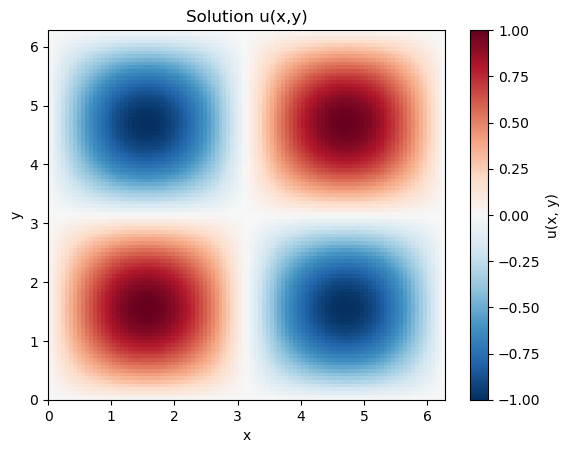

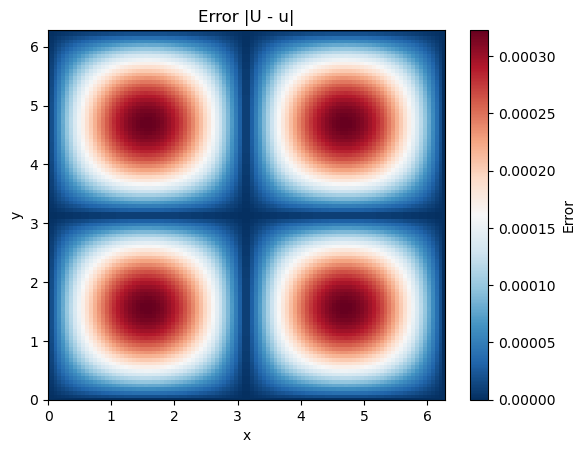

In [2]:
import numpy
import matplotlib.pyplot as plt
import scipy.sparse as sparse
import scipy.sparse.linalg as linalg

# Problem specification
m = 100
x = numpy.linspace(0, 2.0 * numpy.pi, m + 2)
y = numpy.linspace(0, 2.0 * numpy.pi, m + 2)
delta_x = 2.0 * numpy.pi / (m + 1)

# Construct matrix A
e = numpy.ones(m)
T = sparse.spdiags([e, -4.0 * e, e], [-1, 0, 1], m, m)
S = sparse.spdiags([e, e], [-1, 1], m, m)
I = sparse.eye(m)

A = sparse.kron(I, T) + sparse.kron(S, I)
A = A / delta_x**2

# Right-hand-side
X, Y = numpy.meshgrid(x[1:-1], y[1:-1])
f = -2.0 * numpy.sin(X) * numpy.sin(Y)

# Solve system
U = numpy.zeros((m + 2, m + 2))
U[1:-1, 1:-1] = linalg.spsolve(A, f.reshape(m**2, order='F')).reshape((m, m), order='F')

# Error calculation
X, Y = numpy.meshgrid(x, y)
error = numpy.linalg.norm((x[1] - x[0]) * (U - numpy.sin(X) * numpy.sin(Y)), ord=1)
print("Error:", error)

# Plot solution
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

sol_plot = axes.pcolor(X, Y, U, cmap=plt.get_cmap('RdBu_r'))
axes.set_title("Solution u(x,y)")
axes.set_xlabel("x")
axes.set_ylabel("y")
axes.set_xlim((0.0, 2.0 * numpy.pi))
axes.set_ylim((0.0, 2.0 * numpy.pi))

cbar = fig.colorbar(sol_plot, ax=axes)
cbar.set_label("u(x, y)")

# Plot error
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

sol_plot = axes.pcolor(X, Y, numpy.abs(U - numpy.sin(X) * numpy.sin(Y)), cmap=plt.get_cmap('RdBu_r'))
axes.set_title("Error |U - u|")
axes.set_xlabel("x")
axes.set_ylabel("y")
axes.set_xlim((0.0, 2.0 * numpy.pi))
axes.set_ylim((0.0, 2.0 * numpy.pi))

cbar = fig.colorbar(sol_plot, ax=axes)
cbar.set_label("Error")

plt.show()

### **Akurasi dan Stabilitas**

Seperti pada kasus satu dimensi, pertanyaan penting yang perlu diperhatikan adalah apakah skema numerik yang digunakan bersifat konvergen. Untuk mengetahuinya, kita perlu menganalisis local truncation error (LTE)  serta stabilitas metode yang digunakan.

Local truncation error (LTE) didefinisikan sebagai

$$
\begin{aligned}
\tau_{ij} &= \frac{1}{\Delta x^2} 
\left(
u(x_{i-1}, y_{j}) + 
u(x_{i+1}, y_{j}) + 
u(x_{i}, y_{j-1}) + 
u(x_{i}, y_{j+1}) 
- 4u(x_{i}, y_{j})
\right) - f(x_i, y_j)
\end{aligned}
$$
Untuk mengevaluasi atau menghitung ekspresi tersebut, kita perlu menggunakan **pengembangan deret Taylor** pada setiap arah di sekitar titik yang sedang ditinjau.

Untuk menghitung ekspresi tersebut, kita menggunakan **pengembangan deret Taylor** pada setiap arah di sekitar titik $(x_i, y_j)$.

### Arah x

Deret Taylor pada arah $x$ dapat dituliskan sebagai

$$
\begin{aligned}
u(x_{i+1}, y_j) &= u(x_i, y_j) + \Delta x\,u_x(x_i, y_j) 
+ \frac{\Delta x^2}{2}u_{xx}(x_i, y_j) 
+ \frac{\Delta x^3}{6}u_{xxx}(x_i, y_j) 
+ \frac{\Delta x^4}{24}u_{xxxx}(x_i, y_j) 
+ \mathcal{O}(\Delta x^5)
\\
u(x_{i-1}, y_j) &= u(x_i, y_j) - \Delta x\,u_x(x_i, y_j) 
+ \frac{\Delta x^2}{2}u_{xx}(x_i, y_j) 
- \frac{\Delta x^3}{6}u_{xxx}(x_i, y_j) 
+ \frac{\Delta x^4}{24}u_{xxxx}(x_i, y_j) 
+ \mathcal{O}(\Delta x^5)
\end{aligned}
$$

### Arah y

Dengan cara yang sama, deret Taylor pada arah $y$ adalah

$$
\begin{aligned}
u(x_i, y_{j+1}) &= u(x_i, y_j) + \Delta y\,u_y(x_i, y_j) 
+ \frac{\Delta y^2}{2}u_{yy}(x_i, y_j) 
+ \frac{\Delta y^3}{6}u_{yyy}(x_i, y_j) 
+ \frac{\Delta y^4}{24}u_{yyyy}(x_i, y_j) 
+ \mathcal{O}(\Delta y^5)
\\
u(x_i, y_{j-1}) &= u(x_i, y_j) - \Delta y\,u_y(x_i, y_j) 
+ \frac{\Delta y^2}{2}u_{yy}(x_i, y_j) 
- \frac{\Delta y^3}{6}u_{yyy}(x_i, y_j) 
+ \frac{\Delta y^4}{24}u_{yyyy}(x_i, y_j) 
+ \mathcal{O}(\Delta y^5)
\end{aligned}
$$

Dengan menggunakan pengembangan deret Taylor pada arah $y$, maka **local truncation error (LTE)** dapat dituliskan sebagai

$$
\tau_{ij} = \frac{1}{12}\Delta x^2 (u_{xxxx} + u_{yyyy}) + \mathcal{O}(\Delta x^4)
$$

Sistem persamaan linear untuk LTE kemudian dapat ditulis dalam bentuk

$$
A_{\Delta x} E_{\Delta x} = -\tau_{\Delta x}
$$

di mana matriks $A$ merupakan **matriks diskretisasi** yang telah dibentuk sebelumnya.  
Perlu diperhatikan bahwa **urutan persamaan tidak mempengaruhi analisis error**.

### Stabilitas

Untuk menganalisis **stabilitas pada norma 2**, kita dapat melihat **nilai eigen (eigenvalues)** dari sistem tersebut. Nilai eigennya adalah

$$
\lambda_{pq} =
\frac{2}{\Delta x^2}
\left[
(\cos(p\pi\Delta x) - 1) +
(\cos(q\pi\Delta x) - 1)
\right]
$$

dengan **vektor eigen (eigenvectors)**

$$
v^{p,q}_{ij} =
\sin(p\pi i\Delta x)\sin(q\pi j\Delta x)
$$

Karena semua nilai eigen **bernilai negatif** (artinya matriks $A$ bersifat **negative definite**), maka nilai eigen yang paling dekat dengan nol adalah

$$
\lambda_{11} = -2\pi^2 + \mathcal{O}(\Delta x^2)
$$

Hal ini menghasilkan **spectral radius**

$$
\rho((A^{\Delta x})^{-1}) =
\frac{1}{\lambda_{11}}
\approx
-\frac{1}{2\pi^2}
$$

Batas ini dapat digunakan untuk menunjukkan bahwa metode tersebut **stabil**, sehingga diskretisasi yang digunakan juga **konvergen**.

### Condition Number

Besaran lain yang penting untuk dianalisis adalah **condition number** dari matriks $A$, yang didefinisikan sebagai

$$
\kappa(A) = ||A||\,||A^{-1}||
$$

Pada norma 2, kita sudah mengetahui sifat dari $A^{-1}$. Dari nilai eigen yang diperoleh sebelumnya, kita juga dapat menentukan **spectral radius** dari matriks $A$.

Nilai eigen terbesar adalah

$$
\lambda_{mm} \approx -\frac{8}{\Delta x^2}
$$

Sehingga **condition number** menjadi

$$
\kappa_2(A) =
\frac{4}{\pi^2 \Delta x^2}
=
\mathcal{O}\left(\frac{1}{\Delta x^2}\right)
$$

Hal ini menunjukkan bahwa matriks $A$ akan menjadi **semakin tidak stabil secara numerik (ill-conditioned)** ketika

$$
\Delta x \rightarrow 0
$$

**Menghitung nilai eigen**

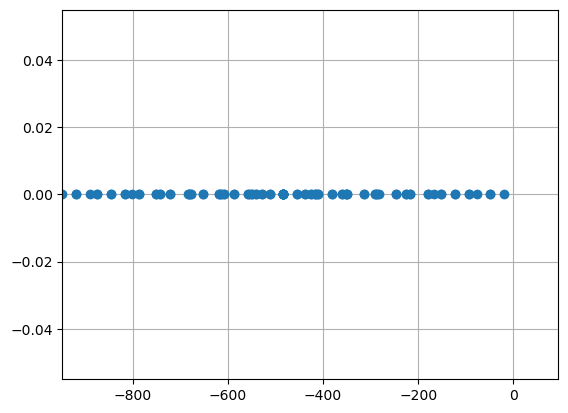

In [2]:
# Hitung nilai eigen
m = 10
delta_x = 1.0 / float(m + 1)
eig_vals = numpy.empty(m**2)
for (i, p) in enumerate(numpy.arange(1, m + 1)):
    for (j, q) in enumerate(numpy.arange(1, m + 1)):
        eig_vals[i * m + j] = 2.0 / delta_x**2 * ((numpy.cos(p * numpy.pi * delta_x) - 1.0) +
                                                  (numpy.cos(q * numpy.pi * delta_x) - 1.0))

# Plot nilai eigen dari Laplasian 5-titik
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(eig_vals.real, eig_vals.imag, 'o')
axes.grid(True)
axes.set_xlim(numpy.amin(eig_vals), -numpy.amin(eig_vals) * 0.1)
plt.show()


### **Laplacian 9-Titik**

Selain pendekatan **stencil 5-titik**, terdapat metode lain untuk mendiskretisasi operator Laplacian $\nabla^2$, yaitu **stencil 9-titik**. Pendekatan ini menggunakan sembilan titik di sekitar titik pusat dan dinyatakan sebagai

$$
\nabla^2 u_{ij} =
\frac{1}{6 \Delta x^2}
\left(
4u_{i-1,j} + 4u_{i+1,j} +
4u_{i,j-1} + 4u_{i,j+1} +
u_{i-1,j-1} + u_{i+1,j-1} +
u_{i+1,j+1} + u_{i-1,j+1}
- 20u_{i,j}
\right)
$$

Seperti sebelumnya, **local truncation error (LTE)** dari pendekatan ini dapat dihitung dan diperoleh

$$
\tau_{ij} =
\frac{\Delta x^2}{12}
\left(
u_{xxxx} + 2u_{xxyy} + u_{yyyy}
\right)
+
\mathcal{O}(\Delta x^4)
$$

Jika diperhatikan, suku turunan pada ekspresi tersebut dapat dituliskan kembali sebagai

$$
u_{xxxx} + 2u_{xxyy} + u_{yyyy}
=
\nabla^2(\nabla^2 u)
\equiv
\nabla^4 u
$$

yang merupakan Laplacian dari Laplacian , atau dikenal sebagai **operator biharmonik**.

Jika kita kembali pada **PDE awal**, maka hubungan ini dapat dituliskan sebagai

$$
\begin{aligned}
\nabla^2 u &= f \\
\nabla^2(\nabla^2 u) &= \nabla^2 f
\end{aligned}
$$

Dengan demikian, suku galat (error term) dapat diperoleh secara langsung dengan mengambil **Laplacian dari ruas kanan persamaan diferensial awal**.

Pendekatan ini juga dapat menghasilkan **metode dengan orde akurasi yang lebih tinggi**. Jika kita mendefinisikan

$$
f_{ij}
=
f(x_i, y_j)
+
\frac{\Delta x^2}{12}
\nabla^2 f(x_i, y_j)
$$

maka suku berikutnya pada LTE dapat dihilangkan.

Hal ini tetap dapat dilakukan meskipun fungsi $f(x,y)$ hanya diketahui pada titik-titik diskret, karena Laplacian dari $f$ masih dapat dihitung menggunakan **stencil 5-titik**.